# InsurePredict: Health Insurance Premium Analysis
# Objective: To predict medical insurance costs (charges) based on individual factors like age, BMI, smoking habits, and region using Linear Regression.
# Techniques: Missing Value Imputation, Categorical Encoding (Mapping & Dummies), Feature Scaling (StandardScaler), Linear Regression Modeling.

# Part-1: Data Exploration and Pre-processing

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\ML_Projects\ML_Project_6.txt")
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [4]:
data["children"] = data["children"].fillna(0)

In [5]:
data["bmi"] = data["bmi"].fillna(data["bmi"].mean())

In [6]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


### Plot Distribution

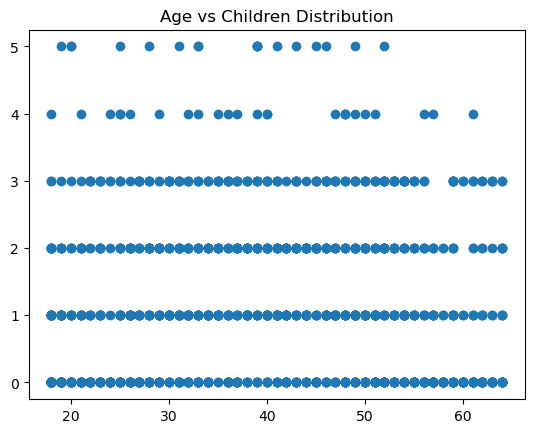

In [7]:
plt.scatter(data["age"],data["children"])
plt.title('Age vs Children Distribution')
plt.show()

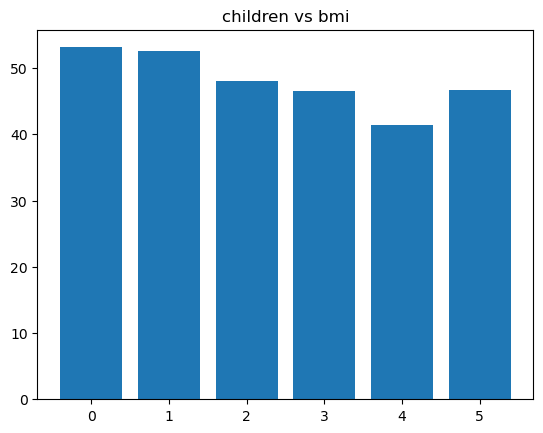

In [8]:
plt.bar(data["children"],data["bmi"])
plt.title('children vs bmi')
plt.show()

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
data["region"].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

### Feature Encoding

In [11]:
data['sex'] = data['sex'].map({'male':0,'female':1})

data['smoker'] = data['smoker'].map({'no':0,'yes':1})

### Feature Scaling

In [12]:
data = pd.get_dummies(data,columns=["region"])

In [13]:
data

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,False,True,False,False
1334,18,1,31.920,0,0,2205.98080,True,False,False,False
1335,18,1,36.850,0,0,1629.83350,False,False,True,False
1336,21,1,25.800,0,0,2007.94500,False,False,False,True


### Devide feature and target variable

In [14]:
x = data.drop("charges",axis=1)
y = data["charges"]

In [15]:
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()

In [16]:
x = scale.fit_transform(x)

# Part-2: Working with Models

### Data train test split and Model build & train

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [18]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=42)

In [19]:
model = LinearRegression()

In [20]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
model.score(x_train,y_train)

0.7417255854683333

In [22]:
model.score(x_test,y_test)

0.7835929767120722

In [23]:
model.coef_

array([ 3.60914902e+03,  9.29533694e+00,  2.05488506e+03,  5.12478869e+02,
        9.54425109e+03,  1.98583641e+02,  3.98323298e+01, -8.64671891e+01,
       -1.48478594e+02])

In [24]:
model.intercept_

np.float64(13314.335941867355)

### Model Evalution

In [25]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error,r2_score

In [26]:
ypri = model.predict(x_test)
ypri

array([ 8969.55027444,  7068.74744287, 36858.41091155,  9454.67850053,
       26973.17345656, 10864.11316424,   170.28084137, 16903.45028662,
        1092.43093614, 11218.34318352, 28101.68455267,  9377.73460205,
        5263.0595179 , 38416.04221107, 40255.82339284, 37098.25353123,
       15240.39392306, 35912.88264434,  9112.52398703, 31461.92108909,
        3847.68845883, 10130.12001517,  2370.54189389,  7140.21550828,
       11301.76782638, 12961.65366224, 14509.47251876,  6159.8976107 ,
        9963.85857263,  2177.85718217,  9115.93673493, 13073.68932159,
        4561.82376202,  3408.20756033,  4459.81359745, 13032.06505076,
        1979.99357292,  8813.28303302, 33271.29124448, 32585.51583927,
        3908.76090964,  4326.10774721, 14142.81326533, 11423.45494846,
        8774.13955311, 12097.28051001,  5281.57353499,  3150.5596042 ,
       35494.46461214,  9150.1124786 , 15836.84575621,  2343.57470069,
       12364.78414194,  1482.29488266, 13389.06105161, 12573.57395972,
      

In [27]:
mean_squared_error(y_test,ypri)

33596915.851361476

In [28]:
mean_absolute_error(y_test,ypri)

4181.194473753654

In [29]:
root_mean_squared_error(y_test,ypri)

5796.284659276274

In [30]:
r2_score(y_test,ypri)

0.7835929767120722